In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import torch

In [2]:
LOOKBACK  = 100
HORIZON   = 30
BATCH     = 32

CYCLICAL_SOURCES = [
    'B.Dongying Road2',
    'E.People\'s Hall1',
    'E.People\'s Hall2',
    'D.Xing\'an South Road1',
    'D.Xing\'an South Road2',
    'G.Xinhua Square1',
    'G.Xinhua Square2',
]

master = pd.read_csv("../data/master_congestion_final.csv")
cyclical = master[master['source'].isin(CYCLICAL_SOURCES)].copy()

# Build sliding window sequences per location
def make_sequences(series, lookback, horizon):
    X, y = [], []
    for i in range(len(series) - lookback - horizon):
        X.append(series[i : i + lookback])
        y.append(series[i + lookback : i + lookback + horizon])
    return np.array(X), np.array(y)

all_X, all_y = [], []

for src in CYCLICAL_SOURCES:
    subset = cyclical[cyclical['source'] == src].sort_values('frame_num')
    scores = subset['congestion_score'].values.astype(np.float32)
    
    X, y = make_sequences(scores, LOOKBACK, HORIZON)
    all_X.append(X)
    all_y.append(y)
    print(f"{src:<35} sequences: {len(X)}")

all_X = np.concatenate(all_X, axis=0)
all_y = np.concatenate(all_y, axis=0)
print(f"\nTotal sequences: {all_X.shape}")
print(f"Input shape:  {all_X.shape}  →  (samples, lookback)")
print(f"Target shape: {all_y.shape}  →  (samples, horizon)")

# Train / val / test split — 70 / 15 / 15
n = len(all_X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = all_X[:train_end],  all_y[:train_end]
X_val,   y_val   = all_X[train_end:val_end], all_y[train_end:val_end]
X_test,  y_test  = all_X[val_end:],    all_y[val_end:]

print(f"\nTrain: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

B.Dongying Road2                    sequences: 13990
E.People's Hall1                    sequences: 14604
E.People's Hall2                    sequences: 8879
D.Xing'an South Road1               sequences: 8784
D.Xing'an South Road2               sequences: 11728
G.Xinhua Square1                    sequences: 23584
G.Xinhua Square2                    sequences: 19129

Total sequences: (100698, 100)
Input shape:  (100698, 100)  →  (samples, lookback)
Target shape: (100698, 30)  →  (samples, horizon)

Train: 70488  Val: 15105  Test: 15105


In [6]:
class CongestionDataset(Dataset):
    def __init__(self, X, y):
        # Shape: (samples, lookback, 1) — Transformer expects (seq, batch, features)
        self.X = torch.tensor(X).unsqueeze(-1)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(CongestionDataset(X_train, y_train),
                          batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(CongestionDataset(X_val, y_val),
                          batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(CongestionDataset(X_test, y_test),
                          batch_size=BATCH, shuffle=False)

print(f"Batches per epoch — train: {len(train_loader)}  val: {len(val_loader)}")

Batches per epoch — train: 2203  val: 473


In [3]:
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(1))  # (max_len, 1, d_model)

    def forward(self, x):
        # x: (seq_len, batch, d_model)
        return self.dropout(x + self.pe[:x.size(0)])


class TrafficTransformer(nn.Module):
    def __init__(self,
                 input_dim=1,
                 d_model=64,
                 nhead=4,
                 num_encoder_layers=3,
                 dim_feedforward=128,
                 dropout=0.1,
                 lookback=100,
                 horizon=30):
        super().__init__()
        self.lookback = lookback
        self.horizon  = horizon

        # Project scalar input to d_model dimensions
        self.input_proj = nn.Linear(input_dim, d_model)

        self.pos_enc = PositionalEncoding(d_model, max_len=lookback + 10,
                                          dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False   # expects (seq, batch, feature)
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_encoder_layers
        )

        # Decode: use last hidden state to predict full horizon
        self.decoder = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, horizon)
        )

    def forward(self, x):
        # x: (batch, lookback, 1)
        x = x.permute(1, 0, 2)          # → (lookback, batch, 1)
        x = self.input_proj(x)           # → (lookback, batch, d_model)
        x = self.pos_enc(x)              # → (lookback, batch, d_model)
        x = self.transformer_encoder(x) # → (lookback, batch, d_model)
        x = x[-1]                        # last timestep → (batch, d_model)
        return self.decoder(x)           # → (batch, horizon)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = TrafficTransformer(
    lookback=LOOKBACK, horizon=HORIZON
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Using device: cpu
Trainable parameters: 112,734


C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [7]:
EPOCHS    = 50
LR        = 1e-3
PATIENCE  = 8   # early stopping

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=4, factor=0.5
)
criterion = nn.MSELoss()

best_val_loss = float('inf')
patience_counter = 0
history = {'train': [], 'val': []}

for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────────
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── Validate ───────────────────────────────────────
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(X_batch)
            val_loss += criterion(pred, y_batch).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    print(f"Epoch {epoch:03d} | train={train_loss:.5f} | val={val_loss:.5f}")

    # ── Early stopping ─────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../data/best_transformer.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print(f"\nBest val loss: {best_val_loss:.5f}")

Epoch 001 | train=0.00464 | val=0.00152
Epoch 002 | train=0.00216 | val=0.00143
Epoch 003 | train=0.00190 | val=0.00136
Epoch 004 | train=0.00184 | val=0.00138
Epoch 005 | train=0.00178 | val=0.00162
Epoch 006 | train=0.00175 | val=0.00156
Epoch 007 | train=0.00172 | val=0.00156
Epoch 008 | train=0.00171 | val=0.00139
Epoch 009 | train=0.00161 | val=0.00135
Epoch 010 | train=0.00160 | val=0.00132
Epoch 011 | train=0.00159 | val=0.00130
Epoch 012 | train=0.00157 | val=0.00132
Epoch 013 | train=0.00156 | val=0.00135
Epoch 014 | train=0.00157 | val=0.00140
Epoch 015 | train=0.00156 | val=0.00134


KeyboardInterrupt: 

Test MAE:  0.0380
Test RMSE: 0.0492


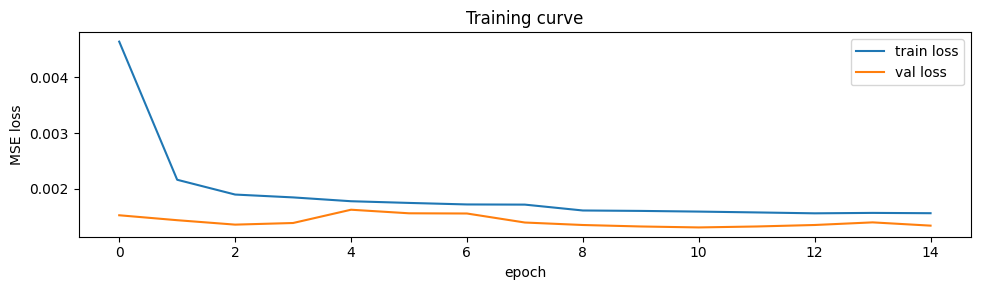

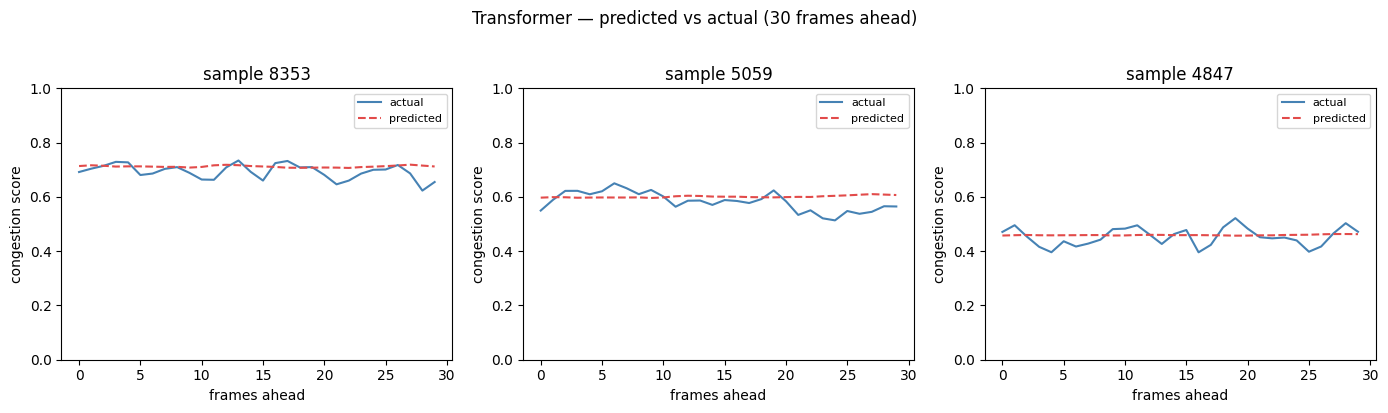

In [8]:
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load('../data/best_transformer.pt'))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        pred = model(X_batch.to(device)).cpu().numpy()
        all_preds.append(pred)
        all_true.append(y_batch.numpy())

preds = np.concatenate(all_preds)
trues = np.concatenate(all_true)

mae  = np.mean(np.abs(preds - trues))
rmse = np.sqrt(np.mean((preds - trues) ** 2))
print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# Plot training curve
plt.figure(figsize=(10, 3))
plt.plot(history['train'], label='train loss')
plt.plot(history['val'],   label='val loss')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.title('Training curve')
plt.tight_layout()
plt.savefig('../data/training_curve.png', dpi=150)
plt.show()

# Plot 3 sample predictions vs ground truth
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, ax in enumerate(axes):
    idx = np.random.randint(len(preds))
    ax.plot(trues[idx], label='actual',    color='steelblue', linewidth=1.5)
    ax.plot(preds[idx], label='predicted', color='#E24B4A',
            linewidth=1.5, linestyle='--')
    ax.set_ylim(0, 1)
    ax.set_xlabel('frames ahead')
    ax.set_ylabel('congestion score')
    ax.set_title(f'sample {idx}')
    ax.legend(fontsize=8)

plt.suptitle('Transformer — predicted vs actual (30 frames ahead)', y=1.02)
plt.tight_layout()
plt.savefig('../data/predictions.png', dpi=150)
plt.show()